In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer

sns.set_style("whitegrid")

In [3]:
DATA_PATH = "../data/raw/delivery_data.csv"

preprocessor = DataPreprocessor(DATA_PATH)

df = preprocessor.load_data()

Loaded dataset shape: (144867, 24)


In [4]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

       data          trip_creation_time  \
0  training  2018-09-20 02:35:36.476840   
1  training  2018-09-20 02:35:36.476840   
2  training  2018-09-20 02:35:36.476840   
3  training  2018-09-20 02:35:36.476840   
4  training  2018-09-20 02:35:36.476840   

                                 route_schedule_uuid route_type  \
0  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
1  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
2  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
3  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
4  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   

                 trip_uuid source_center                 source_name  \
0  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
1  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
2  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
3  trip-153741093647649320  IND388121AAA  Anand_VU

source_name                       293
destination_name                  261
route_schedule_uuid                 0
data                                0
route_type                          0
trip_uuid                           0
source_center                       0
trip_creation_time                  0
destination_center                  0
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64


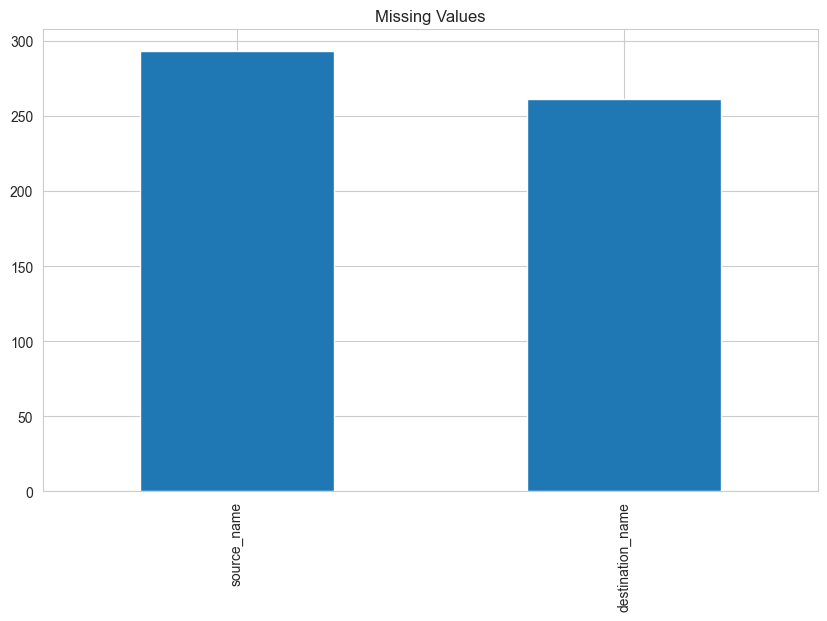

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

plt.figure(figsize=(10,6))

missing[missing > 0].plot(kind="bar")

plt.title("Missing Values")

plt.show()

In [6]:
df = preprocessor.clean_data(df)

engineer = FeatureEngineer()

df = engineer.create_temporal_features(df)

df = engineer.create_targets(df)


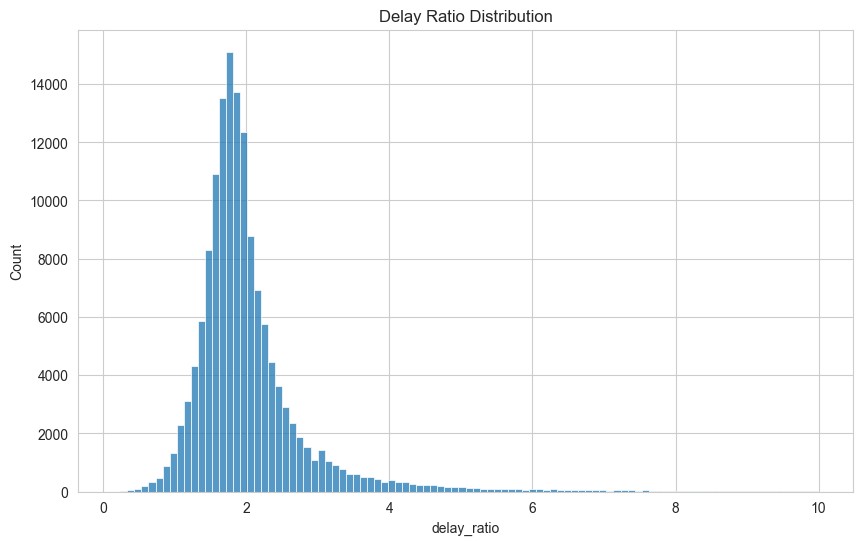

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(df["delay_ratio"], bins=100)

plt.title("Delay Ratio Distribution")

plt.show()

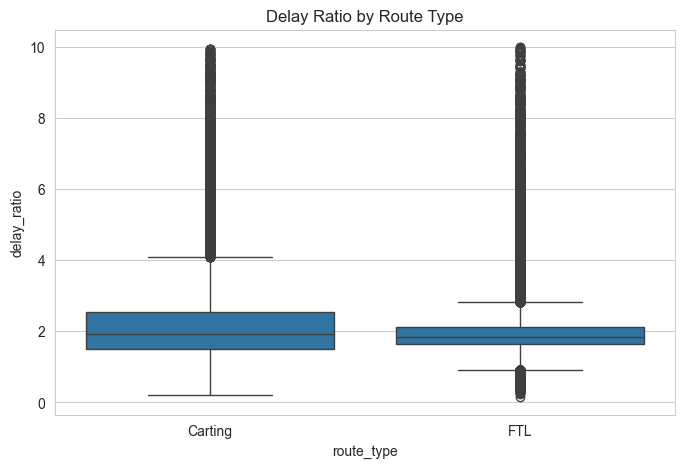

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="route_type",
    y="delay_ratio",
    data=df
)

plt.title("Delay Ratio by Route Type")

plt.show()

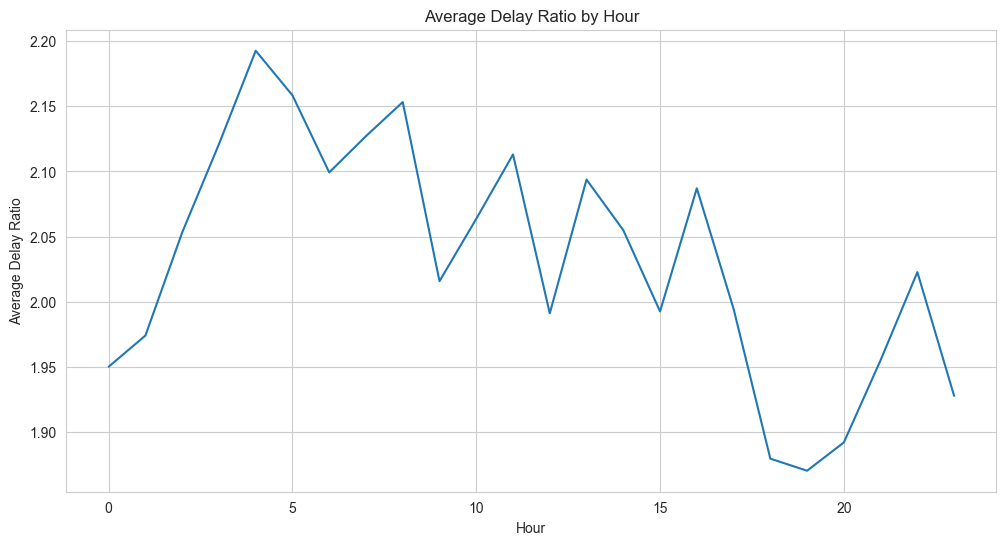

In [9]:
hourly_delay = (
    df.groupby("hour")["delay_ratio"]
    .mean()
)

plt.figure(figsize=(12,6))

hourly_delay.plot()

plt.title("Average Delay Ratio by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Delay Ratio")

plt.show()

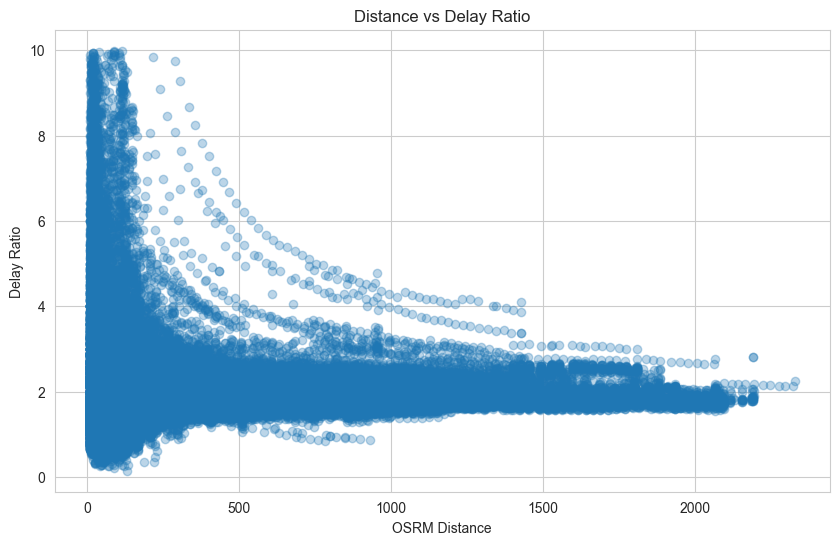

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["osrm_distance"],
    df["delay_ratio"],
    alpha=0.3
)

plt.xlabel("OSRM Distance")

plt.ylabel("Delay Ratio")

plt.title("Distance vs Delay Ratio")

plt.show()

In [11]:
sla_rate = df["sla_breach"].mean()

print(f"SLA Breach Rate: {sla_rate:.2%}")

SLA Breach Rate: 95.67%


In [12]:
corridor_df = engineer.build_corridor_features(df)

print(corridor_df.head())

top_corridors = corridor_df.sort_values(
    by="mean_delay_ratio",
    ascending=False
).head(10)

print(top_corridors)

  source_center destination_center  mean_delay_ratio  delay_variance  \
0  IND000000AAL       IND411033AAA          2.678377        1.291174   
1  IND000000AAQ       IND700028AAB          6.285714        3.835948   
2  IND000000AAS       IND783370AAC          1.924721        0.200800   
3  IND000000AAZ       IND444203AAA          4.531673        1.998161   
4  IND000000AAZ       IND444303AAA          3.347826        1.275992   

   avg_distance  avg_actual_time  sla_breach_rate  trip_count  
0     20.911341        63.702703              1.0          37  
1     12.518075        78.250000              1.0           4  
2     36.861711        50.555556              1.0          18  
3     52.518967       181.666667              1.0           3  
4     45.696067       122.333333              1.0           3  
     source_center destination_center  mean_delay_ratio  delay_variance  \
1008  IND400072AAI       IND000000AFS          9.416667             NaN   
1009  IND400072AAJ       IND40003

In [13]:
df.to_parquet(
    "../data/processed/cleaned_data.parquet",
    index=False
)

print("EDA Completed Successfully")

EDA Completed Successfully
